# Projeto Integrado: Balneabilidade das Praias de Aracaju
**Modelagem Estatística (Regressão)**

**Equipe do Projeto:**
* Allan Fabrício
* Gustavo Passos
* Jefferson Pereira
* Miguel

**Orientador:** Prof. Dr. Gilson Pereira

---

## Parte 1: Proposta de Projeto - Rede Neural para Classificação de Balneabilidade

### 1. Descrição do Dataset
O projeto utiliza o cruzamento de dois bancos de dados públicos referentes ao ano de 2025:
* **INMET (Dados Meteorológicos):** Variáveis independentes (precipitação, vento, umidade, pressão).
* **ADEMA (Dados Microbiológicos):** Variável dependente (concentração de coliformes fecais nas praias de Aracaju).

**Características dos Dados:**
* **Quantidade e Tipos de Dados:** Após o sincronismo temporal (*merge*) das planilhas, teremos instâncias diárias compostas por atributos contínuos numéricos (ex: mm de chuva, m/s de vento) e um atributo alvo (*Target*).
* **Dados Nulos ou Faltantes:** A base do INMET possui falhas de sensoriamento e dados nulos (especialmente no final do ano), que são tratados via preenchimento direcional (`ffill`). Na junção com a ADEMA, linhas com ausência completa de medição laboratorial são descartadas (`dropna`).
* **Valores das Classes Categóricas (O Problema de Classificação):** Transformaremos o dado numérico bruto de coliformes em uma classe binária, baseada no limite regulatório do CONAMA (1.000 NMP/100mL):
    * `Classe 0 (Própria)`: Água segura para banho.
    * `Classe 1 (Imprópria)`: Alerta de contaminação.

### 2. Proposta de Rede a ser Construída
A arquitetura proposta é um **Perceptron Multicamadas (MLP)** focado em classificação binária, estruturado da seguinte forma:
* **Camada de Entrada:** 4 neurônios correspondentes aos tensores climáticos (Chuva Acumulada, Vento, Umidade e Pressão).
* **Camadas Ocultas:** Duas camadas densas (ex: 32 e 16 neurônios) utilizando a função de ativação não-linear **ReLU**, permitindo que a rede entenda os picos de saturação de escoamento da rede pluvial.
* **Camada de Saída:** 1 único neurônio utilizando a função de ativação **Sigmoid**, que entregará a probabilidade (de 0% a 100%) da praia estar imprópria naquele dia.

### 3. Organização dos Dados para o Treinamento
* **Separação (Train/Test Split):** 70% das amostras meteorológicas/laboratoriais serão usadas para treinar a rede, e 30% reservadas como dados inéditos para testar a acurácia.
* **Pré-processamento e Escalonamento:** Redes neurais são sensíveis à escala. A precipitação (ex: 150 mm) e a pressão atmosférica (ex: 1012 mB) serão normalizadas usando a padronização **Z-Score** (`StandardScaler`), equalizando o peso matemático das variáveis climáticas antes de entrarem na rede.

### 4. Linguagem, Bibliotecas, Ambiente e Tecnologias
* **Linguagem Base:** Python 3.
* **Framework de Inteligência Artificial:** `TensorFlow/Keras` para montagem, compilação (função de perda `binary_crossentropy` e otimizador `Adam`) e treinamento por épocas.
* **Manipulação e Visualização:** `Pandas` (ETL), `Scikit-Learn` (divisão, métricas de precisão/recall) e `Matplotlib`.
* **Ambiente de Desenvolvimento:** Google Colab, permitindo execução na nuvem e reprodutibilidade imediata.

---

## Parte 2: Avaliação Comparativa - Regressão Simples vs. Regressão Múltipla

Para compreender o comportamento estatístico destas variáveis antes de alimentar a rede neural, avaliamos o ajuste da correlação linear. O bloco de código abaixo calcula o incremento do Coeficiente de Determinação ($R^2$) ao transitar de um modelo univariado (apenas Chuva) para um multivariado (Clima Completo).

---

## Parte 3: Modelagem Estatística Linear (ADEMA x INMET)

### 1. Entendendo os Modelos e Suas Equações

#### Regressão Linear Simples
Modela o comportamento de uma variável resposta linearmente dependente de um único fator explicativo.
$$
Y = \beta_0 + \beta_1 X + \epsilon
$$
Onde $Y$ é o nível de contaminação (Log de Coliformes), $X$ é a variável de entrada (Chuva acumulada de 7 dias), $eta_0$ é o coeficiente interceptor basal, $eta_1$ representa a inclinação da reta (sensibilidade do ponto à chuva), e $\epsilon$ indica o resíduo do modelo.

#### Regressão Linear Múltipla
Expandido para capturar sistemas complexos, mapeando a resposta baseando-se em múltiplos vetores de forças simultâneos.
$$
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3 + \beta_4 X_4 + \epsilon
$$
Onde incorporamos, além da chuva ($X_1$), as variáveis mecânicas do vento ($X_2$), umidade relativa ($X_3$) e a pressão atmosférica local ($X_4$).

### 2. O Papel Estratégico do $R^2$ na Tomada de Decisão da ADEMA

O Coeficiente de Determinação ($R^2$) expressa a porcentagem da variância dos dados reais que o modelo matemático consegue explicar:
$$
R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}
$$

**Como o $R^2$ se transforma em ação prática para a ADEMA?**

1. **Mecanismo de Alerta Prévio Confiável:** Se um ponto da orla de Aracaju exibe um $R^2$ elevado (ex: 0,80 ou 80%) na Regressão Múltipla, significa que o clima governa diretamente a balneabilidade daquele local. A ADEMA pode acionar o modelo de previsão do tempo do INMET para os próximos 7 dias e emitir alertas preventivos automatizados de "Praia Imprópria" para a população via aplicativo ou placas, sem precisar aguardar as 48 horas de cultivo físico da amostra em laboratório.
2. **Investigação Prática de Poluição Clandestina:** Se o $R^2$ de uma praia específica for extremamente baixo (ex: menos de 20%), o modelo está provando estatisticamente que a chuva ou o clima *não explicam* as oscilações de coliformes ali. Isso sinaliza para a ADEMA que a poluição naquele ponto decorre de uma força externa perene e independente do tempo chuvoso — como lançamentos contínuos de esgoto clandestino ou passivos ambientais na foz do rio. A equipe de fiscalização pode, portanto, ignorar o monitoramento climático e agir diretamente in loco com auditoria de tubulações em tempo seco.
3. **Análise de Custo-Benefício de Sensores:** Ao monitorar o incremento numérico do $R^2$ ($\Delta R^2$) da transição do modelo simples para o múltiplo, a ADEMA quantifica se a compra e manutenção de sensores meteorológicos caros adicionam poder de decisão real que justifique o gasto de verba pública.

Sincronizando as tabelas meteorológicas e de balneabilidade (2025)...
Dados preparados com sucesso.



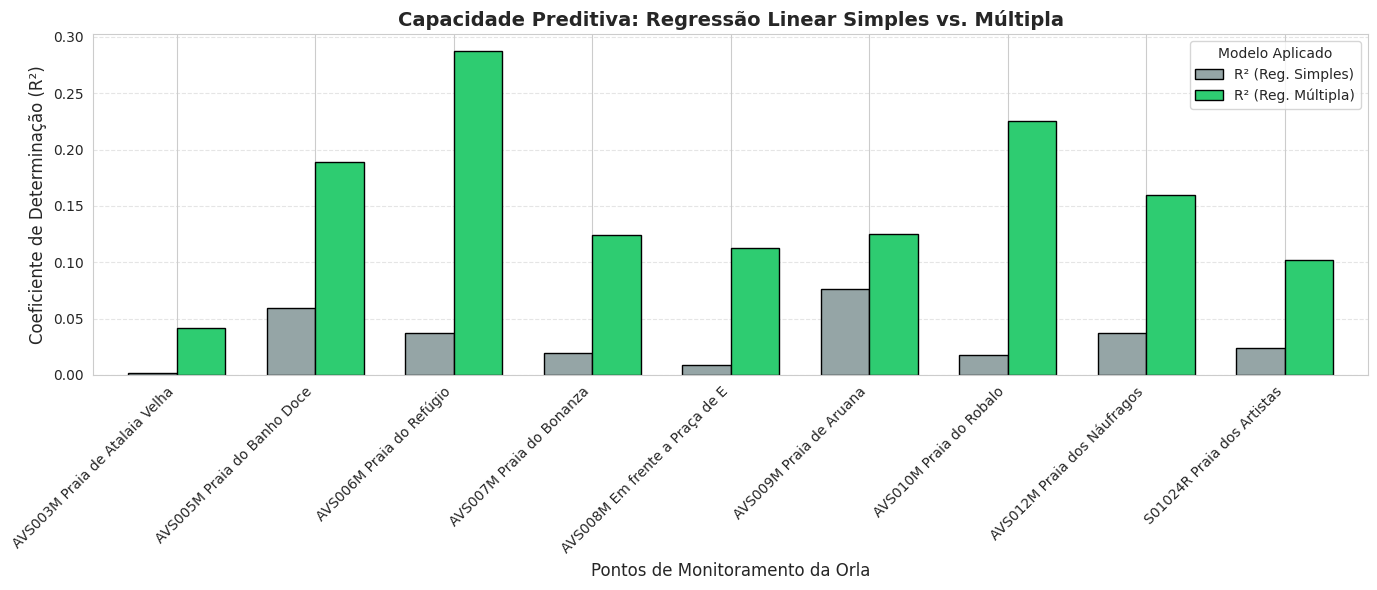


--- TABELA DE GANHO ESTATÍSTICO ---


,Praia,R² (Reg. Simples),R² (Reg. Múltipla),Ganho (Delta)
0,AVS003M Praia de Atalaia Velha,0.0021,0.0416,0.0395
1,AVS005M Praia do Banho Doce,0.0593,0.1887,0.1294
2,AVS006M Praia do Refúgio,0.0373,0.2879,0.2505
3,AVS007M Praia do Bonanza,0.0192,0.1244,0.1053
4,AVS008M Em frente a Praça de E,0.0090,0.1124,0.1035
5,AVS009M Praia de Aruana,0.0766,0.1253,0.0487
6,AVS010M Praia do Robalo,0.0181,0.2256,0.2076
7,AVS012M Praia dos Náufragos,0.0369,0.1595,0.1226
8,S01024R Praia dos Artistas,0.0242,0.1022,0.0780


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings

sns.set_style('whitegrid')
warnings.filterwarnings('ignore')

# 1. CARREGAMENTO E ETL (ADEMA + INMET)
print("Sincronizando as tabelas meteorológicas e de balneabilidade (2025)...")

try:
    df_inmet = pd.read_csv('dados_inmet_aracaju_2025.csv', sep=';')
    df_adema = pd.read_csv('dados_adema_aracaju_2025.csv', sep=',')
except FileNotFoundError:
    print("\n[ERRO] Faça o upload de 'dados_inmet_aracaju_2025.csv' e 'dados_adema_aracaju_2025.csv' no Colab.\n")
    raise

# Limpeza ADEMA
df_adema.columns = df_adema.columns.str.replace('\n', ' ').str.replace('\r', '').str.strip()

# Limpeza e Tipagem INMET
df_inmet.replace('null', np.nan, inplace=True)
cols_medidas = df_inmet.columns[1:]
for col in cols_medidas:
    if df_inmet[col].dtype == object:
        df_inmet[col] = df_inmet[col].str.replace(',', '.').astype(float)

df_inmet['Data Medicao'] = pd.to_datetime(df_inmet['Data Medicao'])
df_inmet.ffill(inplace=True) # Tratamento de Nulos

col_chuva = 'PRECIPITACAO TOTAL, DIARIO (AUT)(mm)'
df_inmet['Prec_7d'] = df_inmet[col_chuva].rolling(window=7, min_periods=1).sum()

# Sincronismo (Merge)
df_adema['Data'] = pd.to_datetime(df_adema['Data'])
colunas_praias = [col for col in df_adema.columns if col != 'Data']
df_final = pd.merge(df_adema, df_inmet, left_on='Data', right_on='Data Medicao', how='inner')

# Transformação Logarítmica para Estabilização da Regressão
for praia in colunas_praias:
    df_final[f'Log_{praia}'] = np.log1p(df_final[praia])

print("Dados preparados com sucesso.\n")

# 2. REGRESSÃO SIMPLES VS. MÚLTIPLA
features_simples = ['Prec_7d']
features_multiplas = [
    'Prec_7d',
    'VENTO, VELOCIDADE MEDIA DIARIA (AUT)(m/s)',
    'UMIDADE RELATIVA DO AR, MEDIA DIARIA (AUT)(%)',
    'PRESSAO ATMOSFERICA MEDIA DIARIA (AUT)(mB)'
]

resultados = []

for praia in colunas_praias:
    # Filtrar dados válidos para a praia atual
    df_reg = df_final.dropna(subset=features_multiplas + [f'Log_{praia}'])
    if len(df_reg) < 5: continue

    X_s = df_reg[features_simples].values
    X_m = df_reg[features_multiplas].values
    y = df_reg[f'Log_{praia}'].values

    # Fit Simples
    mod_s = LinearRegression().fit(X_s, y)
    r2_s = max(0, r2_score(y, mod_s.predict(X_s)))

    # Fit Múltiplo
    mod_m = LinearRegression().fit(X_m, y)
    r2_m = max(0, r2_score(y, mod_m.predict(X_m)))

    nome_curto = praia.split('-')[0].strip() + " " + praia.split('–')[0].split('-')[-1].strip()

    resultados.append({
        'Praia': nome_curto[:30],
        'R² (Reg. Simples)': round(r2_s, 4),
        'R² (Reg. Múltipla)': round(r2_m, 4),
        'Ganho (Delta)': round(r2_m - r2_s, 4)
    })

df_comp = pd.DataFrame(resultados)

# 3. GERAÇÃO DO GRÁFICO COMPARATIVO
df_plot = df_comp.set_index('Praia')[['R² (Reg. Simples)', 'R² (Reg. Múltipla)']]
fig, ax = plt.subplots(figsize=(14, 6))
df_plot.plot(kind='bar', ax=ax, color=['#95a5a6', '#2ecc71'], edgecolor='black', width=0.7)

plt.title('Capacidade Preditiva: Regressão Linear Simples vs. Múltipla', fontsize=14, weight='bold')
plt.ylabel('Coeficiente de Determinação (R²)', fontsize=12)
plt.xlabel('Pontos de Monitoramento da Orla', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Modelo Aplicado', fontsize=10)
plt.tight_layout()
plt.show()

print("\n--- TABELA DE GANHO ESTATÍSTICO ---")
display(df_comp)